# Knowledge Tracing on ASSISTments 2009 — Project Summary

**Question:** Given a student's past answers (which skills, right/wrong, in order),
predict whether they'll get the *next* problem right.

## Setup (provenance — the honest fine print)
- **Data:** ASSISTments 2009–2010 "skill builder", RAW/uncorrected file,
  **deduplicated by `order_id`** (525,534 → 346,860 true interactions; ~34% were
  multi-skill duplicate rows).
- **Scale:** 4,217 students · 26,688 problems · 123 skills · 68% overall correct.
- **Split:** by **whole student**, 80/20 (3,373 train / 844 test), overlap verified = ∅.
  Time-respecting throughout: every prediction of step *t* uses only steps *< t*.
- **Metric:** ROC-AUC on next-interaction correctness (accuracy reported where relevant).

## Results
| Model | Idea | Test AUC |
|---|---|---|
| Baseline A | predict global correct rate for everyone | 0.500 |
| Baseline B | per-problem historical difficulty | 0.683 |
| Pure IRT | learned student + item embeddings (one-hot) | 0.673 |
| Logistic + history | item difficulty + student's overall prior accuracy | 0.751 |
| **PFA (best)** | **+ per-skill prior accuracy** | **0.760** |
| DKT (LSTM, len 200) | learns student memory from the raw sequence | 0.758 |
| DKT (LSTM, len 500) | same, more history per student | 0.752 |

## Finding
A tuned **DKT (~0.75–0.76) does not beat a well-built per-skill PFA baseline (0.760)**
on this dataset; it decisively beats the item and IRT baselines. This reproduces the
known result (*"How Deep is Knowledge Tracing?"*) that strong classical baselines rival
deep sequence models. Pure IRT *underperformed* item difficulty because a learned
per-student ability can't transfer to unseen students — the core reason KT needs
history-based models.

## Honest caveats
- Used the RAW (deduped-by-first-skill) file → 112 skills survive; some multi-skill info lost.
- DKT tuning was deliberately limited to avoid repeated test-set peeking (itself a leak).
- Longer sequences didn't help because the extra data was concentrated in a few power users.

## What I learned

**1. Leakage — the discipline that shaped everything.**
Leakage is when the model gets access to information it shouldn't have, which
inflates the score into a lie. It comes in two forms, and I had to guard against both:
- *Cross-student:* if the same student is in both train and test, the model doesn't
  really predict their next move — it just reproduces what it already learned about
  them. Fix: split by `user_id` so no student is in both sets (and I verified the
  overlap was empty).
- *Temporal:* within one student, to predict step *t* the model must only see steps
  *< t* — never their future. Fix: sort by time and build features with a strict
  "before this row" rule (the `cumsum − current` trick).

**2. Why AUC, not accuracy.**
The data is 68% "correct", so a model that blindly guesses "correct" for everyone
scores 0.686 accuracy while doing nothing useful — the base rate flatters it.
AUC isn't fooled: it measures *ranking* (can the model score a correct answer above
a wrong one?). Baseline A gave everyone the identical prediction, so it can't rank at
all — and AUC *automatically* returns 0.500 for that. So accuracy (0.686) hid what
AUC (0.500) exposed: a model with zero ability to tell answers apart.

**3. Why IRT lost to item difficulty — identity vs. behavior.**
Item difficulty is already a strong baseline (0.683). But the real reason pure IRT
came in *below* it: IRT learns an *ability number per student*, and the test students
were never seen in training — so those ability numbers were all zeros and added
nothing. A learned *identity* ("student #14 = ability 0.7") can't transfer to a
stranger. The fix was to use *behavior* instead: a student's own prior accuracy so far.
That's a pattern ("whoever's doing well tends to keep doing well") that works on *any*
new student — and it jumped the score from 0.683 → 0.751.

**4. Overfitting, and how I caught it.**
When I trained DKT for too many epochs, the training loss kept falling but the test
AUC *dropped* (0.752 → 0.727). That divergence — train loss down, held-out score down —
is the signature of overfitting: the model stopped learning general patterns and
started memorizing the quirks of the 3,271 training students (noise that doesn't
transfer). Three fixes: (a) carve a *validation* set out of train, (b) measure AUC each
epoch and keep the model from the peak epoch (early stopping), (c) dropout. Key rule:
never use the *test* set to decide when to stop — that tunes the model to test and
gives dishonest numbers.

**5. Deep didn't automatically win — the humbling lesson.**
The LSTM (0.758) only tied my per-skill PFA baseline (0.760); more compute and
complexity didn't buy a better result. What matters more is understanding how the data
is structured and finding the real patterns in it. Sometimes the simple, well-built
model is as good as — or better than — the fancy one. Build strong baselines first, and
don't mistake "I used a neural net" for "I did better."

In [1]:
import pandas as pd
import numpy as np
print("toolbox works")

toolbox works


In [2]:
df = pd.read_csv("data/skill_builder_data.csv", encoding="latin-1")
df.shape

<ipykernel>:1: DtypeWarning: Columns (0: skill_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/skill_builder_data.csv", encoding="latin-1")


(525534, 30)

In [3]:
df = pd.read_csv("data/skill_builder_data.csv", encoding="latin-1", low_memory=False)

In [4]:
df.columns

Index(['order_id', 'assignment_id', 'user_id', 'assistment_id', 'problem_id',
       'original', 'correct', 'attempt_count', 'ms_first_response',
       'tutor_mode', 'answer_type', 'sequence_id', 'student_class_id',
       'position', 'type', 'base_sequence_id', 'skill_id', 'skill_name',
       'teacher_id', 'school_id', 'hint_count', 'hint_total', 'overlap_time',
       'template_id', 'answer_id', 'answer_text', 'first_action',
       'bottom_hint', 'opportunity', 'opportunity_original'],
      dtype='str')

In [5]:
df.head()

,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [6]:
df['correct'].value_counts()

correct
1    357085
0    168449
Name: count, dtype: int64

In [7]:
df['user_id'].nunique()

4217

In [8]:
df['correct'].mean()

np.float64(0.6794707859053839)

In [9]:
df['problem_id'].nunique()

26688

In [10]:
df['skill_id'].nunique()

123

In [11]:
len(df)

525534

In [12]:
df.groupby('user_id').size()

user_id
14        51
21825     29
51933      1
51950      6
52613      7
        ... 
96295    712
96296    674
96297    724
96298    496
96299    484
Length: 4217, dtype: int64

<Axes: >

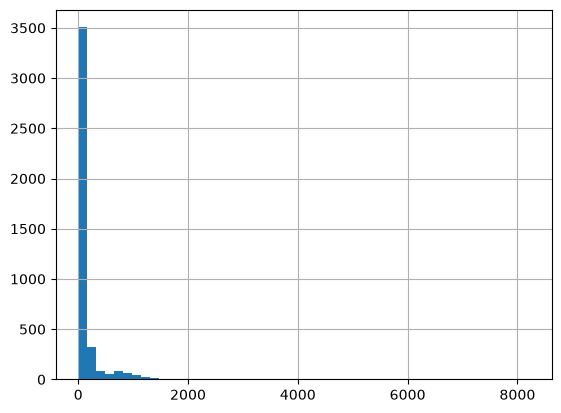

In [13]:
df.groupby('user_id').size().hist(bins=50)

In [14]:
df.groupby('user_id').size().describe()

count    4217.000000
mean      124.622718
std       307.594047
min         1.000000
25%        10.000000
50%        27.000000
75%        95.000000
max      8214.000000
dtype: float64

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
students = df['user_id'].unique()
train_students, test_students = train_test_split(students, test_size=0.2, random_state=42)

In [17]:
len(train_students), len(test_students)

(3373, 844)

In [18]:
train_df = df[df['user_id'].isin(train_students)]
test_df  = df[df['user_id'].isin(test_students)]

In [19]:
len(train_df), len(test_df)

(414281, 111253)

In [20]:
set(train_df['user_id']) & set(test_df['user_id'])

set()

In [21]:
global_rate = train_df['correct'].mean()
global_rate

np.float64(0.6778466789449673)

In [22]:
from sklearn.metrics import roc_auc_score
import numpy as np

preds_A = np.full(len(test_df), global_rate)          # same prediction for every test row
roc_auc_score(test_df['correct'], preds_A)

0.5

In [23]:
item_difficulty = train_df.groupby('problem_id')['correct'].mean()
item_difficulty

problem_id
83        0.333333
84        0.000000
85        0.000000
86        0.625000
249       0.000000
            ...   
207344    1.000000
207345    1.000000
207346    1.000000
207347    1.000000
207348    1.000000
Name: correct, Length: 25870, dtype: float64

In [24]:
preds_B = test_df['problem_id'].map(item_difficulty)
preds_B

16        0.765957
17        0.868421
23        0.545455
24        0.538462
25        0.633333
            ...   
525186    0.666667
525187    0.588235
525188    0.695652
525189    0.700000
525190    0.714286
Name: problem_id, Length: 111253, dtype: float64

In [25]:
preds_B.isna().sum()

np.int64(1918)

In [26]:
preds_B = preds_B.fillna(global_rate)

In [27]:
preds_B.isna().sum()

np.int64(0)

In [28]:
roc_auc_score(test_df['correct'], preds_B)

0.6832744371792474

## v0 — Baselines (ASSISTments 2009, RAW/uncorrected version)
Split: by student, 80/20 (3373 train / 844 test students), verified no overlap.
- Baseline A (global correct rate = 0.678):  AUC = 0.500
- Baseline B (per-item difficulty, NaN→global rate):  AUC = 0.683  ← BAR TO BEAT

In [29]:
from sklearn.metrics import accuracy_score

labels_A = (preds_A >= 0.5)                          # turn probabilities into True/False guesses
accuracy_score(test_df['correct'], labels_A)

0.6855185927570493

In [30]:
labels_B = (preds_B >= 0.5)
accuracy_score(test_df['correct'], labels_B)

0.6951363109309412

## v0 — Baselines (ASSISTments 2009, RAW/uncorrected version)
Split: by student, 80/20 (3373 train / 844 test students), verified no overlap.
- Baseline A (global correct rate = 0.678):  AUC = 0.500,  Accuracy = 0.686
- Baseline B (per-item difficulty, NaN→global rate):  AUC = 0.683,  Accuracy = 0.695  ← BAR TO BEAT
Lesson: accuracy (0.686 vs 0.695) hid what AUC (0.500 vs 0.683) exposed — imbalanced data (68% correct) inflates accuracy. Trust AUC.

In [31]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown="ignore")
X_train = enc.fit_transform(train_df[["user_id", "problem_id"]])
X_test  = enc.transform(test_df[["user_id", "problem_id"]])
X_train.shape

(414281, 29243)

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, train_df["correct"])

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [33]:
preds_irt = model.predict_proba(X_test)[:, 1]
roc_auc_score(test_df["correct"], preds_irt)

0.6726795214842082

In [34]:
df_sorted = df.sort_values(["user_id", "order_id"]).copy()
df_sorted[["user_id", "order_id", "correct"]].head(15)

,user_id,order_id,correct
3957,14,21617623,0
94047,14,21617623,0
172411,14,21617623,0
3958,14,21617632,1
94048,14,21617632,1
172412,14,21617632,1
3959,14,21617641,0
94049,14,21617641,0
172413,14,21617641,0
3960,14,21617650,0


In [35]:
df["order_id"].nunique()

346860

In [36]:
len(df)

525534

In [37]:
df_clean = df.drop_duplicates(subset="order_id", keep="first").copy()
len(df_clean)

346860

In [38]:
train_df = df_clean[df_clean["user_id"].isin(train_students)]
test_df  = df_clean[df_clean["user_id"].isin(test_students)]
len(train_df), len(test_df)

(270514, 76346)

In [39]:
df_clean = df_clean.sort_values(["user_id", "order_id"])   # time order within each student
grp = df_clean.groupby("user_id")

df_clean["prior_count"]   = grp.cumcount()
df_clean["prior_correct"] = grp["correct"].cumsum() - df_clean["correct"]

df_clean[["user_id", "order_id", "correct", "prior_count", "prior_correct"]].head(10)

,user_id,order_id,correct,prior_count,prior_correct
3957,14,21617623,0,0,0
3958,14,21617632,1,1,0
3959,14,21617641,0,2,1
3960,14,21617650,0,3,1
3961,14,21617659,0,4,1
3962,14,21617667,0,5,1
3963,14,21617675,0,6,1
3964,14,21617692,0,7,1
459208,14,21617718,0,8,1
459209,14,21617722,0,9,1


In [40]:
df_clean["prior_accuracy"] = (df_clean["prior_correct"] / df_clean["prior_count"]).fillna(0.5)
df_clean[["user_id", "correct", "prior_count", "prior_correct", "prior_accuracy"]].head(6)

,user_id,correct,prior_count,prior_correct,prior_accuracy
3957,14,0,0,0,0.500000
3958,14,1,1,0,0.000000
3959,14,0,2,1,0.500000
3960,14,0,3,1,0.333333
3961,14,0,4,1,0.250000
3962,14,0,5,1,0.200000


In [41]:
global_rate     = train_df["correct"].mean()
item_difficulty = train_df.groupby("problem_id")["correct"].mean()
df_clean["item_difficulty"] = df_clean["problem_id"].map(item_difficulty).fillna(global_rate)

In [42]:
feature_cols = ["item_difficulty", "prior_accuracy"]
train_mask = df_clean["user_id"].isin(train_students)
test_mask  = df_clean["user_id"].isin(test_students)

X_train = df_clean.loc[train_mask, feature_cols]
X_test  = df_clean.loc[test_mask,  feature_cols]
y_train = df_clean.loc[train_mask, "correct"]
y_test  = df_clean.loc[test_mask,  "correct"]
X_train.shape

(270514, 2)

In [43]:
model2 = LogisticRegression()
model2.fit(X_train, y_train)
preds_v1 = model2.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, preds_v1)

0.7510562501633941

In [44]:
model2.coef_

array([[5.4027634 , 3.20560355]])

## v1 — Logistic (item difficulty + student prior accuracy)   [PFA/AFM-style]
Data: raw file, DEDUPED by order_id (525,534 → 346,860 rows). Same student split.
- Pure IRT (student+item one-hot): AUC = 0.673  ← FAILED — student ID doesn't transfer to unseen students (cold-start)
- v1 (item_difficulty + prior_accuracy, leak-safe history via cumcount/cumsum − current): AUC = 0.751  ← NEW BAR
Lesson: transferable behavioral features (history-so-far) generalize to new students; per-student ID params do not.

In [45]:
df_clean["skill_id"].isna().sum()

np.int64(63755)

In [46]:
df_clean["skill_id"] = df_clean["skill_id"].fillna(-1)

grp_skill = df_clean.groupby(["user_id", "skill_id"])
df_clean["prior_skill_count"]    = grp_skill.cumcount()
df_clean["prior_skill_correct"]  = grp_skill["correct"].cumsum() - df_clean["correct"]
df_clean["prior_skill_accuracy"] = (df_clean["prior_skill_correct"] / df_clean["prior_skill_count"]).fillna(0.5)

In [47]:
feature_cols = ["item_difficulty", "prior_accuracy", "prior_skill_accuracy"]

X_train = df_clean.loc[train_mask, feature_cols]
X_test  = df_clean.loc[test_mask,  feature_cols]

model3 = LogisticRegression()
model3.fit(X_train, y_train)
preds_v1b = model3.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, preds_v1b)

0.7597812499086656

## v1 (final) — PFA-style logistic regression
Features: item_difficulty + prior_accuracy (overall) + prior_skill_accuracy (per user×skill).
Note: 63,755 rows (~18%) had no skill_id → grouped as -1.
- item only:                 0.683
- + overall history:         0.751   (+0.068)
- + per-skill history:       0.760   (+0.009  ← diminishing returns → motivates DKT)
v1 FINAL BAR = 0.760

In [48]:
import torch
torch.__version__

'2.13.0+cpu'

In [49]:
skill_ids = df_clean["skill_id"].unique()
skill2idx = {s: i for i, s in enumerate(skill_ids)}
num_skills = len(skill2idx)
df_clean["skill_idx"] = df_clean["skill_id"].map(skill2idx)
num_skills

113

In [50]:
sequences = {}
for user, g in df_clean.groupby("user_id"):
    sequences[user] = (g["skill_idx"].tolist(), g["correct"].tolist())

len(sequences)

4217

In [51]:
sequences[14]

([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 2, 3, 3, 2, 3, 2, 2],
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0])

In [52]:
data = []
for user, (skills, corrects) in sequences.items():
    if len(skills) < 2:            # need at least one (input → next) pair
        continue
    tokens = [s + c * num_skills for s, c in zip(skills, corrects)]
    input_tokens  = tokens[:-1]    # reads interactions 0 .. L-2
    target_skills = skills[1:]     # the NEXT skill at each step
    target_labels = corrects[1:]   # the NEXT correctness at each step
    data.append((user, input_tokens, target_skills, target_labels))

len(data)

4097

In [53]:
user, inp, tsk, tlab = data[0]   # data[0] happens to be student 14
print("input tokens  :", inp[:6])
print("target skills :", tsk[:6])
print("target labels :", tlab[:6])

input tokens  : [0, 113, 0, 0, 0, 0]
target skills : [0, 0, 0, 0, 0, 0]
target labels : [1, 0, 0, 0, 0, 0]


In [54]:
train_students_set = set(train_students)
test_students_set  = set(test_students)

train_data = [d for d in data if d[0] in train_students_set]
test_data  = [d for d in data if d[0] in test_students_set]

len(train_data), len(test_data)

(3271, 826)

In [55]:
import torch

MAX_LEN   = 200
PAD_TOKEN = 2 * num_skills          # 226 — a dedicated "nothing here" id

def make_tensors(dataset):
    N = len(dataset)
    X = torch.full((N, MAX_LEN), PAD_TOKEN, dtype=torch.long)   # inputs (start all-padding)
    S = torch.zeros((N, MAX_LEN), dtype=torch.long)             # which skill to predict
    Y = torch.zeros((N, MAX_LEN), dtype=torch.float)           # the 0/1 answer to predict
    M = torch.zeros((N, MAX_LEN), dtype=torch.bool)            # mask: True = real step
    for i, (user, inp, tsk, tlab) in enumerate(dataset):
        L = min(len(inp), MAX_LEN)                              # truncate if too long
        X[i, :L] = torch.tensor(inp[:L])
        S[i, :L] = torch.tensor(tsk[:L])
        Y[i, :L] = torch.tensor(tlab[:L], dtype=torch.float)
        M[i, :L] = True                                         # mark real positions
    return X, S, Y, M

X_train, S_train, Y_train, M_train = make_tensors(train_data)
X_test,  S_test,  Y_test,  M_test  = make_tensors(test_data)
X_train.shape, M_train.sum()

(torch.Size([3271, 200]), tensor(173581))

In [56]:
import torch.nn as nn

class DKT(nn.Module):
    def __init__(self, num_skills, embed_dim=64, hidden_dim=64):
        super().__init__()
        self.embed = nn.Embedding(2 * num_skills + 1, embed_dim, padding_idx=2 * num_skills)
        self.lstm  = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.out   = nn.Linear(hidden_dim, num_skills)

    def forward(self, x):
        e = self.embed(x)        # (batch, len)          -> (batch, len, embed_dim)
        h, _ = self.lstm(e)      # (batch, len, embed)   -> (batch, len, hidden_dim)
        logits = self.out(h)     # (batch, len, hidden)  -> (batch, len, num_skills)
        return logits

model = DKT(num_skills)
model

DKT(
  (embed): Embedding(227, 64, padding_idx=226)
  (lstm): LSTM(64, 64, batch_first=True)
  (out): Linear(in_features=64, out_features=113, bias=True)
)

In [57]:
out = model(X_train[:2])
out.shape

torch.Size([2, 200, 113])

In [58]:
loss_fn = nn.BCEWithLogitsLoss(reduction="none")

logits = model(X_train[:64])                                     # (64, 200, 113)
pred   = logits.gather(2, S_train[:64].unsqueeze(2)).squeeze(2)  # (64, 200)  <- move 1
loss_mat = loss_fn(pred, Y_train[:64])                           # (64, 200)  <- move 2
mask = M_train[:64].float()
loss = (loss_mat * mask).sum() / mask.sum()                      #            <- move 3
loss

tensor(0.6952, grad_fn=<DivBackward0>)

In [59]:
import torch.optim as optim

model     = DKT(num_skills)                              # fresh model, random start
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn   = nn.BCEWithLogitsLoss(reduction="none")

batch_size = 64
n = X_train.shape[0]

for epoch in range(10):
    perm = torch.randperm(n)                             # reshuffle students each pass
    total_loss, n_batches = 0.0, 0
    for i in range(0, n, batch_size):
        idx = perm[i:i + batch_size]
        xb, sb, yb, mb = X_train[idx], S_train[idx], Y_train[idx], M_train[idx].float()

        logits = model(xb)                                       # forward
        pred   = logits.gather(2, sb.unsqueeze(2)).squeeze(2)
        loss   = (loss_fn(pred, yb) * mb).sum() / mb.sum()

        optimizer.zero_grad()                                    # clear old gradients
        loss.backward()                                          # backward
        optimizer.step()                                         # nudge the weights

        total_loss += loss.item(); n_batches += 1
    print(f"epoch {epoch+1:2d}:  avg loss {total_loss / n_batches:.4f}")

epoch  1:  avg loss 0.5890
epoch  2:  avg loss 0.5558
epoch  3:  avg loss 0.5468
epoch  4:  avg loss 0.5398
epoch  5:  avg loss 0.5321
epoch  6:  avg loss 0.5241
epoch  7:  avg loss 0.5204
epoch  8:  avg loss 0.5154
epoch  9:  avg loss 0.5113
epoch 10:  avg loss 0.5049


In [61]:
for epoch in range(20):
    perm = torch.randperm(n)
    total_loss, n_batches = 0.0, 0
    for i in range(0, n, batch_size):
        idx = perm[i:i + batch_size]
        xb, sb, yb, mb = X_train[idx], S_train[idx], Y_train[idx], M_train[idx].float()
        logits = model(xb)
        pred   = logits.gather(2, sb.unsqueeze(2)).squeeze(2)
        loss   = (loss_fn(pred, yb) * mb).sum() / mb.sum()
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item(); n_batches += 1
    print(f"epoch {epoch+11:2d}:  avg loss {total_loss / n_batches:.4f}")

epoch 11:  avg loss 0.5005
epoch 12:  avg loss 0.4955
epoch 13:  avg loss 0.4970
epoch 14:  avg loss 0.4920
epoch 15:  avg loss 0.4842
epoch 16:  avg loss 0.4786
epoch 17:  avg loss 0.4769
epoch 18:  avg loss 0.4749
epoch 19:  avg loss 0.4743
epoch 20:  avg loss 0.4718
epoch 21:  avg loss 0.4668
epoch 22:  avg loss 0.4728
epoch 23:  avg loss 0.4642
epoch 24:  avg loss 0.4726
epoch 25:  avg loss 0.4746
epoch 26:  avg loss 0.4668
epoch 27:  avg loss 0.4640
epoch 28:  avg loss 0.4608
epoch 29:  avg loss 0.4581
epoch 30:  avg loss 0.4553


In [62]:
from sklearn.metrics import roc_auc_score

model.eval()
with torch.no_grad():
    logits = model(X_test)
    pred   = logits.gather(2, S_test.unsqueeze(2)).squeeze(2)   # (826, 200)
    probs  = torch.sigmoid(pred)                                 # logits -> probabilities

mask   = M_test.bool()
y_true = Y_test[mask].numpy()      # real steps only, flattened
y_prob = probs[mask].numpy()

roc_auc_score(y_true, y_prob)

0.7272584895267772

In [63]:
train_sub_students, val_students = train_test_split(list(train_students), test_size=0.15, random_state=42)
train_sub_set, val_set = set(train_sub_students), set(val_students)

train_sub_data = [d for d in train_data if d[0] in train_sub_set]
val_data       = [d for d in train_data if d[0] in val_set]

X_tr,  S_tr,  Y_tr,  M_tr  = make_tensors(train_sub_data)
X_val, S_val, Y_val, M_val = make_tensors(val_data)
len(train_sub_data), len(val_data)

(2782, 489)

In [64]:
class DKT(nn.Module):
    def __init__(self, num_skills, embed_dim=64, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(2 * num_skills + 1, embed_dim, padding_idx=2 * num_skills)
        self.lstm  = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.drop  = nn.Dropout(dropout)
        self.out   = nn.Linear(hidden_dim, num_skills)
    def forward(self, x):
        e = self.embed(x)
        h, _ = self.lstm(e)
        logits = self.out(self.drop(h))
        return logits

In [65]:
def evaluate(model, X, S, Y, M):
    model.eval()
    with torch.no_grad():
        pred = model(X).gather(2, S.unsqueeze(2)).squeeze(2)
        probs = torch.sigmoid(pred)
    m = M.bool()
    return roc_auc_score(Y[m].numpy(), probs[m].numpy())

In [69]:
import copy

model     = DKT(num_skills)
optimizer = optim.Adam(model.parameters(), lr=0.01)
n_tr      = X_tr.shape[0]
best_val, best_state = 0.0, None

for epoch in range(30):
    model.train()
    perm = torch.randperm(n_tr)
    for i in range(0, n_tr, batch_size):
        idx = perm[i:i + batch_size]
        xb, sb, yb, mb = X_tr[idx], S_tr[idx], Y_tr[idx], M_tr[idx].float()
        loss = (loss_fn(model(xb).gather(2, sb.unsqueeze(2)).squeeze(2), yb) * mb).sum() / mb.sum()
        optimizer.zero_grad(); loss.backward(); optimizer.step()

    val_auc = evaluate(model, X_val, S_val, Y_val, M_val)
    flag = ""
    if val_auc > best_val:
        best_val, best_state = val_auc, copy.deepcopy(model.state_dict())
        flag = "  <- best"
    print(f"epoch {epoch+1:2d}:  val AUC {val_auc:.4f}{flag}")

print("best val AUC:", round(best_val, 4))

epoch  1:  val AUC 0.7373  <- best
epoch  2:  val AUC 0.7494  <- best
epoch  3:  val AUC 0.7546  <- best
epoch  4:  val AUC 0.7574  <- best
epoch  5:  val AUC 0.7566
epoch  6:  val AUC 0.7609  <- best
epoch  7:  val AUC 0.7601
epoch  8:  val AUC 0.7608
epoch  9:  val AUC 0.7610  <- best
epoch 10:  val AUC 0.7625  <- best
epoch 11:  val AUC 0.7615
epoch 12:  val AUC 0.7600
epoch 13:  val AUC 0.7609
epoch 14:  val AUC 0.7589
epoch 15:  val AUC 0.7597
epoch 16:  val AUC 0.7585
epoch 17:  val AUC 0.7588
epoch 18:  val AUC 0.7570
epoch 19:  val AUC 0.7575
epoch 20:  val AUC 0.7542
epoch 21:  val AUC 0.7552
epoch 22:  val AUC 0.7535
epoch 23:  val AUC 0.7544
epoch 24:  val AUC 0.7542
epoch 25:  val AUC 0.7523
epoch 26:  val AUC 0.7523
epoch 27:  val AUC 0.7533
epoch 28:  val AUC 0.7521
epoch 29:  val AUC 0.7518
epoch 30:  val AUC 0.7496
best val AUC: 0.7625


In [67]:
model.load_state_dict(best_state)
evaluate(model, X_test, S_test, Y_test, M_test)

0.7578198037566167

In [68]:
MAX_LEN = 500

X_tr,   S_tr,   Y_tr,   M_tr   = make_tensors(train_sub_data)
X_val,  S_val,  Y_val,  M_val  = make_tensors(val_data)
X_test, S_test, Y_test, M_test = make_tensors(test_data)

X_tr.shape, M_tr.sum()

(torch.Size([2782, 500]), tensor(197933))

In [70]:
import copy

model     = DKT(num_skills)
optimizer = optim.Adam(model.parameters(), lr=0.01)
n_tr      = X_tr.shape[0]
best_val, best_state = 0.0, None

for epoch in range(30):
    model.train()
    perm = torch.randperm(n_tr)
    for i in range(0, n_tr, batch_size):
        idx = perm[i:i + batch_size]
        xb, sb, yb, mb = X_tr[idx], S_tr[idx], Y_tr[idx], M_tr[idx].float()
        loss = (loss_fn(model(xb).gather(2, sb.unsqueeze(2)).squeeze(2), yb) * mb).sum() / mb.sum()
        optimizer.zero_grad(); loss.backward(); optimizer.step()

    val_auc = evaluate(model, X_val, S_val, Y_val, M_val)
    flag = ""
    if val_auc > best_val:
        best_val, best_state = val_auc, copy.deepcopy(model.state_dict())
        flag = "  <- best"
    print(f"epoch {epoch+1:2d}:  val AUC {val_auc:.4f}{flag}")

print("best val AUC:", round(best_val, 4))

epoch  1:  val AUC 0.7411  <- best
epoch  2:  val AUC 0.7494  <- best
epoch  3:  val AUC 0.7535  <- best
epoch  4:  val AUC 0.7566  <- best
epoch  5:  val AUC 0.7602  <- best
epoch  6:  val AUC 0.7600
epoch  7:  val AUC 0.7609  <- best
epoch  8:  val AUC 0.7597
epoch  9:  val AUC 0.7592
epoch 10:  val AUC 0.7598
epoch 11:  val AUC 0.7607
epoch 12:  val AUC 0.7585
epoch 13:  val AUC 0.7579
epoch 14:  val AUC 0.7568
epoch 15:  val AUC 0.7579
epoch 16:  val AUC 0.7557
epoch 17:  val AUC 0.7566
epoch 18:  val AUC 0.7539
epoch 19:  val AUC 0.7532
epoch 20:  val AUC 0.7512
epoch 21:  val AUC 0.7523
epoch 22:  val AUC 0.7517
epoch 23:  val AUC 0.7474
epoch 24:  val AUC 0.7473
epoch 25:  val AUC 0.7481
epoch 26:  val AUC 0.7486
epoch 27:  val AUC 0.7468
epoch 28:  val AUC 0.7456
epoch 29:  val AUC 0.7491
epoch 30:  val AUC 0.7498
best val AUC: 0.7609


In [71]:
model.load_state_dict(best_state)
evaluate(model, X_test, S_test, Y_test, M_test)

0.7532227031321476

In [72]:
torch.manual_seed(0)

model     = DKT(num_skills)
optimizer = optim.Adam(model.parameters(), lr=0.01)
# ... rest of the loop unchanged

In [74]:
MAX_LEN = 500

X_tr,   S_tr,   Y_tr,   M_tr   = make_tensors(train_sub_data)
X_val,  S_val,  Y_val,  M_val  = make_tensors(val_data)
X_test, S_test, Y_test, M_test = make_tensors(test_data)

print("train tensor:", X_tr.shape, "| real steps:", M_tr.sum().item())

train tensor: torch.Size([2782, 500]) | real steps: 197933


In [75]:
import copy

torch.manual_seed(0)

model     = DKT(num_skills)
optimizer = optim.Adam(model.parameters(), lr=0.01)
n_tr      = X_tr.shape[0]
best_val, best_state = 0.0, None

for epoch in range(30):
    model.train()
    perm = torch.randperm(n_tr)
    for i in range(0, n_tr, batch_size):
        idx = perm[i:i + batch_size]
        xb, sb, yb, mb = X_tr[idx], S_tr[idx], Y_tr[idx], M_tr[idx].float()
        loss = (loss_fn(model(xb).gather(2, sb.unsqueeze(2)).squeeze(2), yb) * mb).sum() / mb.sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    val_auc = evaluate(model, X_val, S_val, Y_val, M_val)
    flag = ""
    if val_auc > best_val:
        best_val, best_state = val_auc, copy.deepcopy(model.state_dict())
        flag = "  <- best"
    print(f"epoch {epoch+1:2d}:  val AUC {val_auc:.4f}{flag}")

print("best val AUC:", round(best_val, 4))

epoch  1:  val AUC 0.7375  <- best
epoch  2:  val AUC 0.7473  <- best
epoch  3:  val AUC 0.7548  <- best
epoch  4:  val AUC 0.7574  <- best
epoch  5:  val AUC 0.7587  <- best
epoch  6:  val AUC 0.7598  <- best
epoch  7:  val AUC 0.7615  <- best
epoch  8:  val AUC 0.7606
epoch  9:  val AUC 0.7616  <- best
epoch 10:  val AUC 0.7604
epoch 11:  val AUC 0.7603
epoch 12:  val AUC 0.7621  <- best
epoch 13:  val AUC 0.7607
epoch 14:  val AUC 0.7588
epoch 15:  val AUC 0.7589
epoch 16:  val AUC 0.7575
epoch 17:  val AUC 0.7560
epoch 18:  val AUC 0.7574
epoch 19:  val AUC 0.7551
epoch 20:  val AUC 0.7544
epoch 21:  val AUC 0.7553
epoch 22:  val AUC 0.7535
epoch 23:  val AUC 0.7550
epoch 24:  val AUC 0.7533
epoch 25:  val AUC 0.7521
epoch 26:  val AUC 0.7512
epoch 27:  val AUC 0.7523
epoch 28:  val AUC 0.7532
epoch 29:  val AUC 0.7536
epoch 30:  val AUC 0.7511
best val AUC: 0.7621


In [76]:
model.load_state_dict(best_state)
print("TEST AUC:", evaluate(model, X_test, S_test, Y_test, M_test))

TEST AUC: 0.7524501429880872
